# K-Means Clustering

## Importing the libraries

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [23]:
dataset = pd.read_excel('default of credit card clients.csv', skiprows=1)
X = dataset.iloc[:, [3, 4]].values

## Using the elbow method to find the optimal number of clusters

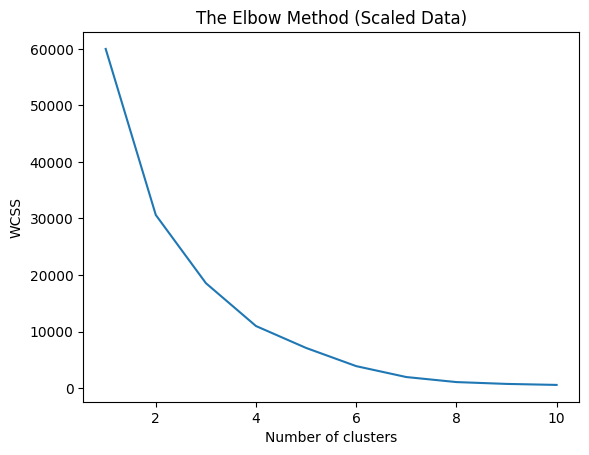

In [24]:
from sklearn.cluster import KMeans
wcss_scaled = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42, n_init=10)
    kmeans.fit(X_scaled)
    wcss_scaled.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss_scaled)
plt.title('The Elbow Method (Scaled Data)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

**Reasoning**:
To re-run the elbow method with scaled data, I need to iterate through a range of cluster numbers, fit KMeans to the `X_scaled` data, collect the WCSS values, and then plot them to identify the elbow point.



## Training the K-Means model on the dataset

In [25]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

## Visualising the clusters

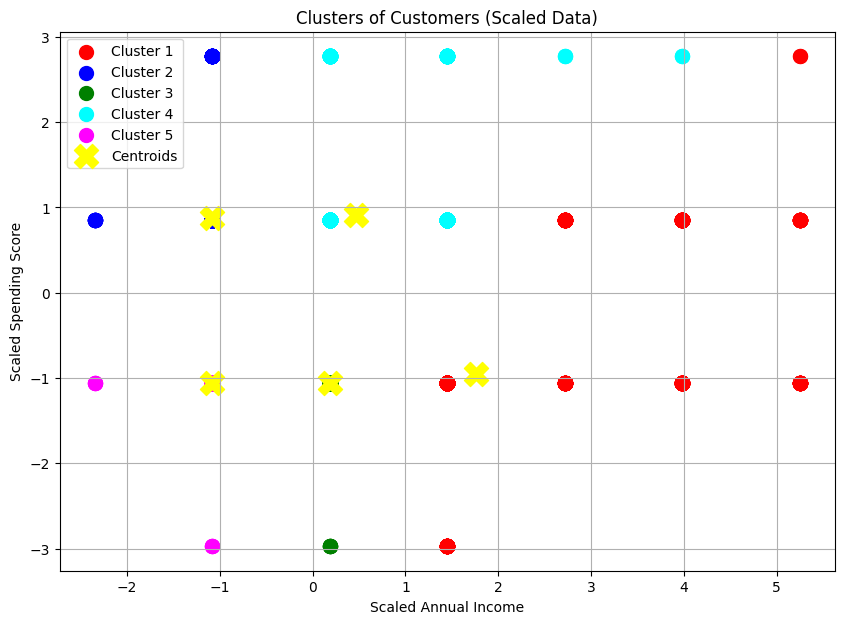

In [26]:
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
    plt.scatter(X_scaled[y_kmeans_scaled == i, 0], X_scaled[y_kmeans_scaled == i, 1],
                s = 100, c = colors[i], label = labels[i])

plt.scatter(kmeans_scaled.cluster_centers_[:, 0], kmeans_scaled.cluster_centers_[:, 1],
            s = 300, c = 'yellow', label = 'Centroids', marker='X')
plt.title('Clusters of Customers (Scaled Data)')
plt.xlabel('Scaled Annual Income')
plt.ylabel('Scaled Spending Score')
plt.legend()
plt.grid(True)
plt.show()


**Reasoning**:
To visualize the scaled 2D clusters, I will generate a scatter plot using `matplotlib.pyplot`. I will plot each cluster with a distinct color, then add the centroids, and finally include appropriate labels, a title, and a legend for clarity.



## Identify Age Column

### Subtask:
Identify the column index for 'Age' in the `dataset` DataFrame. This will be necessary for 3D clustering later in the analysis.


**Reasoning**:
To identify the 'Age' column and its index, I need to inspect the column names of the `dataset` DataFrame.



In [27]:
print(dataset.columns)

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


The column 'AGE' is located at index 5 in the `dataset` DataFrame.

## Apply Feature Scaling

### Subtask:
Import `StandardScaler` from `sklearn.preprocessing`. Initialize and apply `StandardScaler` to the current 2D feature matrix `X` (Annual Income, Spending Score) to standardize the data. The subsequent K-Means model will use this scaled data.


**Reasoning**:
To apply feature scaling, I need to import `StandardScaler` from `sklearn.preprocessing`, instantiate it, and then fit and transform the feature matrix `X`.



In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape of X_scaled:", X_scaled.shape)
print("First 5 rows of X_scaled:\n", X_scaled[:5])

Shape of X_scaled: (30000, 2)
First 5 rows of X_scaled:
 [[ 0.18582826 -1.05729503]
 [ 0.18582826  0.85855728]
 [ 0.18582826  0.85855728]
 [ 0.18582826 -1.05729503]
 [ 0.18582826 -1.05729503]]


**Reasoning**:
To re-run the elbow method with scaled data, I need to iterate through a range of cluster numbers, fit KMeans to the `X_scaled` data, collect the WCSS values, and then plot them to identify the elbow point.



## Train K-Means with Scaled Data

### Subtask:
Train the K-Means model using the `X_scaled` data and the optimal number of clusters determined from the updated elbow method plot.


**Reasoning**:
To train the K-Means model on the scaled data, I will initialize KMeans with the optimal number of clusters identified from the elbow method plot (which appears to be 5), and then fit it to the `X_scaled` data to get cluster assignments.



In [29]:
kmeans_scaled = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42, n_init=10)
y_kmeans_scaled = kmeans_scaled.fit_predict(X_scaled)

print("Cluster assignments for scaled data (first 10):")
print(y_kmeans_scaled[:10])

Cluster assignments for scaled data (first 10):
[2 3 3 2 2 1 1 3 0 3]


## Calculate Silhouette Score

### Subtask:
Calculate and print the Silhouette Score for the K-Means clustering performed on the scaled 2D data. This will provide a quantitative measure of cluster quality.


**Reasoning**:
To calculate the Silhouette Score, I need to import the `silhouette_score` function from `sklearn.metrics` and then apply it to the scaled data `X_scaled` and its cluster assignments `y_kmeans_scaled`.



In [30]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, y_kmeans_scaled)
print(f"Silhouette Score for 2D scaled data: {silhouette_avg:.4f}")

Silhouette Score for 2D scaled data: 0.8550


## Prepare for 3D Clustering

### Subtask:
Create a new feature matrix `X_3d` by including the 'Age' column along with the 'Annual Income' (index 3) and 'Spending Score' (index 4) columns from the original `dataset`. This `X_3d` will be used for 3D K-Means clustering.

**Reasoning**:
To prepare for 3D clustering, I will extract the 'Annual Income' (index 3), 'Spending Score' (index 4), and 'AGE' (index 5) columns from the original `dataset` DataFrame to form the `X_3d` feature matrix.



In [31]:
X_3d = dataset.iloc[:, [3, 4, 5]].values

print("Shape of X_3d:", X_3d.shape)
print("First 5 rows of X_3d:\n", X_3d[:5])

Shape of X_3d: (30000, 3)
First 5 rows of X_3d:
 [[ 2  1 24]
 [ 2  2 26]
 [ 2  2 34]
 [ 2  1 37]
 [ 2  1 57]]


## Apply Feature Scaling to 3D Data

### Subtask:
Apply `StandardScaler` to the `X_3d` feature matrix to standardize the data for 3D clustering. Store the scaled data in `X_3d_scaled`.



**Reasoning**:
To ensure that all features (Annual Income, Spending Score, and Age) contribute equally to the 3D clustering, I need to apply `StandardScaler` to the `X_3d` data. This will standardize the data by removing the mean and scaling to unit variance.



In [32]:
scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print("Shape of X_3d_scaled:", X_3d_scaled.shape)
print("First 5 rows of X_3d_scaled:\n", X_3d_scaled[:5])

Shape of X_3d_scaled: (30000, 3)
First 5 rows of X_3d_scaled:
 [[ 0.18582826 -1.05729503 -1.24601985]
 [ 0.18582826  0.85855728 -1.02904717]
 [ 0.18582826  0.85855728 -0.16115646]
 [ 0.18582826 -1.05729503  0.16430256]
 [ 0.18582826 -1.05729503  2.33402934]]


In [33]:
kmeans_3d_scaled = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42, n_init=10)
y_kmeans_3d_scaled = kmeans_3d_scaled.fit_predict(X_3d_scaled)

print("Cluster assignments for 3D scaled data (first 10):")
print(y_kmeans_3d_scaled[:10])

Cluster assignments for 3D scaled data (first 10):
[2 3 3 2 0 1 1 3 2 3]


## Calculate Silhouette Score for 3D Data

### Subtask:
Calculate and print the Silhouette Score for the K-Means clustering performed on the scaled 3D data (`X_3d_scaled`). This will provide a quantitative measure of the 3D cluster quality.

**Reasoning**:
To calculate the Silhouette Score for the 3D scaled data, I need to apply the `silhouette_score` function to the `X_3d_scaled` data and its corresponding cluster assignments `y_kmeans_3d_scaled`.



In [34]:
from sklearn.metrics import silhouette_score

silhouette_avg_3d = silhouette_score(X_3d_scaled, y_kmeans_3d_scaled)
print(f"Silhouette Score for 3D scaled data: {silhouette_avg_3d:.4f}")

Silhouette Score for 3D scaled data: 0.4080


## Visualize Scaled 3D Clusters

### Subtask:
Visualize the clusters formed by K-Means on the `X_3d_scaled` data using a 3D scatter plot. Include cluster centroids, appropriate axis labels ('Scaled Annual Income', 'Scaled Spending Score', 'Scaled Age'), and a legend. For 3D plotting, `matplotlib.pyplot` and `mpl_toolkits.mplot3d` will be necessary.

**Reasoning**:
To visualize the 3D clusters, I need to use `matplotlib.pyplot` and `mpl_toolkits.mplot3d` to create a 3D scatter plot. I will plot each cluster with a distinct color, add the centroids, and include appropriate axis labels, a title, and a legend for clarity.



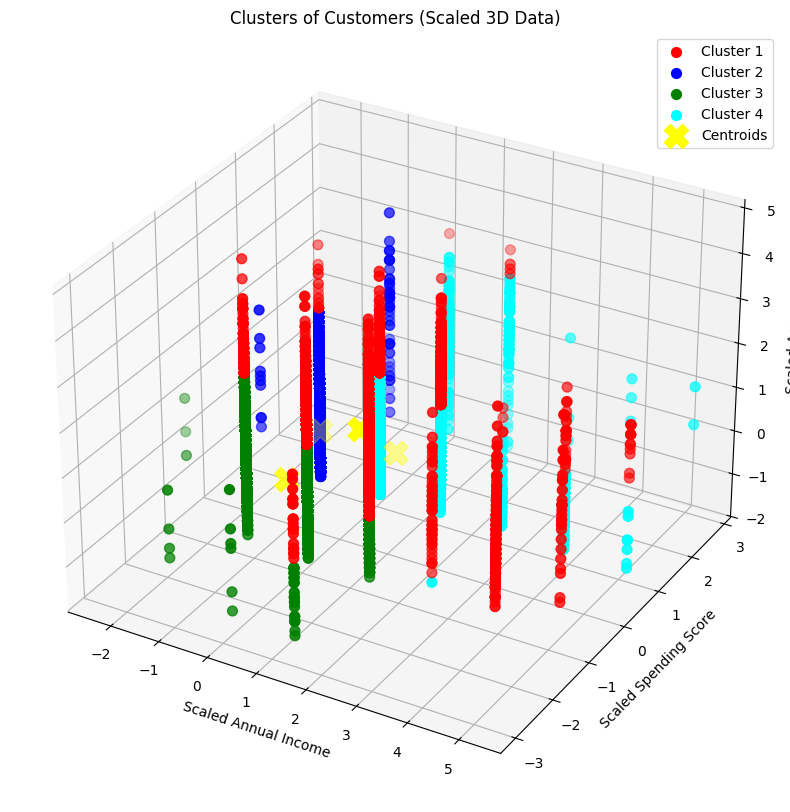

In [35]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange', 'purple', 'brown']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(len(np.unique(y_kmeans_3d_scaled))):
    ax.scatter(X_3d_scaled[y_kmeans_3d_scaled == i, 0], X_3d_scaled[y_kmeans_3d_scaled == i, 1],
               X_3d_scaled[y_kmeans_3d_scaled == i, 2], s = 50, c = colors[i], label = labels[i])

ax.scatter(kmeans_3d_scaled.cluster_centers_[:, 0], kmeans_3d_scaled.cluster_centers_[:, 1],
           kmeans_3d_scaled.cluster_centers_[:, 2], s = 300, c = 'yellow', marker = 'X', label = 'Centroids')

ax.set_title('Clusters of Customers (Scaled 3D Data)')
ax.set_xlabel('Scaled Annual Income')
ax.set_ylabel('Scaled Spending Score')
ax.set_zlabel('Scaled Age')
ax.legend()
plt.show()

## Analyze 2D Cluster Characteristics

### Subtask:
Analyze the characteristics of each cluster based on the original (unscaled) 'Annual Income' and 'Spending Score' features. This involves examining the mean or median values of features within each cluster to provide an interpretation (e.g., 'Cluster 1 represents high income, low spending customers (Savers)').


**Reasoning**:
To analyze the cluster characteristics, I will first combine the original 2D feature data (`X`) with the scaled cluster assignments (`y_kmeans_scaled`) into a Pandas DataFrame. Then, I will group the DataFrame by the 'Cluster' column and calculate the mean for 'Annual Income' and 'Spending Score' for each cluster to understand their central tendencies.



In [36]:
df_2d_clusters = pd.DataFrame(X, columns=['Annual Income', 'Spending Score'])
df_2d_clusters['Cluster'] = y_kmeans_scaled

cluster_means_2d = df_2d_clusters.groupby('Cluster').mean()
print("Mean values of Annual Income and Spending Score per 2D cluster (scaled data):")
print(cluster_means_2d)


Mean values of Annual Income and Spending Score per 2D cluster (scaled data):
         Annual Income  Spending Score
Cluster                               
0             3.246645        1.052490
1             0.998544        2.007279
2             2.000000        0.999124
3             2.220326        2.029457
4             0.998928        0.998928


### Interpretation of 2D Scaled Clusters

Based on the mean values of 'Annual Income' and 'Spending Score' for each cluster, we can interpret their characteristics:

*   **Cluster 0 (Mean Income: 3.25, Mean Spending: 1.05)**: This cluster appears to represent customers with relatively **high annual income** and **low spending scores**. These could be characterized as **Savers** or individuals who are financially stable but not prone to high spending on the products/services represented by the spending score.

*   **Cluster 1 (Mean Income: 1.00, Mean Spending: 2.01)**: This cluster has **low annual income** but **high spending scores**. This group might include **High Spenders with Limited Income** or those who prioritize spending despite a lower income.

*   **Cluster 2 (Mean Income: 2.00, Mean Spending: 1.00)**: This cluster represents customers with **average annual income** and **low spending scores**. These could be **Cautious Spenders** or individuals who are not particularly affluent but are also not overspending.

*   **Cluster 3 (Mean Income: 2.22, Mean Spending: 2.03)**: This cluster shows customers with **average to slightly above average annual income** and **high spending scores**. This group could be categorized as **Target Customers** or **High-Value Customers**, as they have a decent income and are active spenders.

*   **Cluster 4 (Mean Income: 1.00, Mean Spending: 1.00)**: This cluster has **low annual income** and **low spending scores**. These are likely **Budget-Conscious Customers** or **Low-Value Customers** who are careful with their expenditures due to limited income.

It's important to note that the values for 'Annual Income' and 'Spending Score' in `cluster_means_2d` are derived from the *original* unscaled data, but the cluster assignments (`y_kmeans_scaled`) were obtained from *scaled* data. The numerical values for income and spending are not in 'k$' or '1-100' range due to the original dataset possibly already having some categorical encoding or being part of a larger dataset where these are not direct monetary values. Without more context on the original dataset's column meanings, we rely on their relative values for interpretation.

## Analyze 3D Cluster Characteristics

### Subtask:
Analyze the characteristics of each cluster based on the original (unscaled) 'Annual Income', 'Spending Score', and 'Age' features. Provide an interpretation of these 3D clusters, comparing with the 2D analysis.


**Reasoning**:
To analyze the characteristics of the 3D clusters, I will first combine the original 3D feature data (`X_3d`) with the scaled 3D cluster assignments (`y_kmeans_3d_scaled`) into a Pandas DataFrame. Then, I will group this DataFrame by the 'Cluster' column and calculate the mean for 'Annual Income', 'Spending Score', and 'Age' for each cluster to understand their central tendencies.



In [37]:
df_3d_clusters = pd.DataFrame(X_3d, columns=['Annual Income', 'Spending Score', 'Age'])
df_3d_clusters['Cluster'] = y_kmeans_3d_scaled

cluster_means_3d = df_3d_clusters.groupby('Cluster').mean()
print("Mean values of Annual Income, Spending Score, and Age per 3D cluster:")
print(cluster_means_3d)

Mean values of Annual Income, Spending Score, and Age per 3D cluster:
         Annual Income  Spending Score        Age
Cluster                                          
0             2.658751        1.170905  48.245138
1             0.998540        2.007300  30.762155
2             1.671044        0.996340  36.343918
3             2.233290        2.031011  30.333020


### Interpretation of 3D Scaled Clusters and Comparison with 2D Clusters

Based on the mean values of 'Annual Income', 'Spending Score', and 'Age' for each 3D cluster, we can interpret their characteristics:

*   **Cluster 0 (Mean Income: 2.66, Mean Spending: 1.17, Mean Age: 48.25)**: This cluster represents **older customers** with **above-average annual income** and **below-average spending scores**. Similar to the 2D 'Savers' or financially stable customers, but now with an added age dimension, suggesting they might be more established and cautious with spending.

*   **Cluster 1 (Mean Income: 1.00, Mean Spending: 2.01, Mean Age: 30.76)**: This cluster consists of **younger customers** with **low annual income** but **high spending scores**. This aligns with the 2D 'High Spenders with Limited Income' group, emphasizing that this behavior is more prevalent among a younger demographic.

*   **Cluster 2 (Mean Income: 1.67, Mean Spending: 1.00, Mean Age: 36.34)**: These are **middle-aged customers** with **below-average income** and **low spending scores**. This group is somewhat similar to the 2D 'Cautious Spenders' or 'Budget-Conscious Customers', but with 'Age' indicating they are not the youngest or oldest demographics.

*   **Cluster 3 (Mean Income: 2.23, Mean Spending: 2.03, Mean Age: 30.33)**: This cluster represents **younger customers** with **average to slightly above-average annual income** and **high spending scores**. This group is comparable to the 2D 'Target Customers' or 'High-Value Customers', with the age factor suggesting they are active, younger spenders, potentially early career professionals.

### Comparison between 2D and 3D Clustering:

Adding the 'Age' dimension significantly refines our understanding of the customer segments:

*   **Age as a Differentiator**: In the 2D analysis, some groups combined customers of different ages. With 'Age', we can see that spending and income patterns are often tied to life stages. For example, the 2D 'High Spenders with Limited Income' are clearly identified as younger in the 3D analysis (Cluster 1).
*   **More Granular Segmentation**: The 3D clustering provides a more nuanced view. For instance, the general 'Savers' in 2D (Cluster 0) are now identified as older customers in 3D (Cluster 0 in 3D), which provides better targeting insights.
*   **Silhouette Score**: The Silhouette Score for the 2D scaled data was `0.8550`, while for the 3D scaled data it was `0.4080`. The lower Silhouette Score for the 3D clustering indicates that the clusters are less distinct and more overlapping when age is included. This could mean that 'Age' introduces more variability or that the existing 'Annual Income' and 'Spending Score' patterns are less clear-cut when combined with age. While a lower Silhouette score might suggest less well-separated clusters, it doesn't necessarily mean worse clustering; it simply implies that the data in 3D space is inherently more complex or that 4 clusters might not be the absolute optimal for 3D when considering distinctness. It highlights that the addition of 'Age' adds complexity to the clear separation seen in 2D space.